# Homework 9: Classification
### Abdullah Junejo (aj07154)

In [1]:
import pandas as pd
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Q1

In [2]:
df = pd.read_csv('CreditCardData.csv')
df.head()

,Male,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43,560,+
2,a,24.5,0.500,u,g,q,h,1.50,t,f,0,f,g,280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120,0,+


In [3]:
df.replace('?', pd.NA, inplace=True) #Removing Missing Values
df.dropna(inplace=True)
df.head()

,Male,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43,560,+
2,a,24.5,0.500,u,g,q,h,1.50,t,f,0,f,g,280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120,0,+


# Q2

In [4]:
#Replace the Approvedcolumn with 0,1
df['Approved'] = df['Approved'].replace('-', '0')
df['Approved'] = df['Approved'].replace('+', '1')
df['Approved'] = df['Approved'].astype(int)
df['Approved']

0      1
1      1
2      1
3      1
4      1
      ..
685    0
686    0
687    0
688    0
689    0
Name: Approved, Length: 653, dtype: int32

# Q3

In [5]:
#cleaning and converting to numeric values
df['Age'] = df['Age'].astype(float)
df['ZipCode'] = df['ZipCode'].astype(float)
df.head()


,Male,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,1
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,1
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,1
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,1
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,1


In [7]:
#one hot encoding for the non-numeric columns

categoricall = df.select_dtypes(exclude=['int', 'float']).columns.tolist()
print(categoricall)

['Male', 'Married', 'BankCustomer', 'EducationLevel', 'Ethnicity', 'PriorDefault', 'Employed', 'DriversLicense', 'Citizen']


In [9]:
DFF = pd.get_dummies(df, columns=[i for i in categoricall])

# Q4

In [10]:
dTrain, dTest = train_test_split(DFF, test_size=0.3, random_state=100)
DFF.head()

,Age,Debt,YearsEmployed,CreditScore,ZipCode,Income,Approved,Male_a,Male_b,Married_l,...,Ethnicity_z,PriorDefault_f,PriorDefault_t,Employed_f,Employed_t,DriversLicense_f,DriversLicense_t,Citizen_g,Citizen_p,Citizen_s
0,30.83,0.000,1.25,1,202.0,0,1,0,1,0,...,0,0,1,0,1,1,0,1,0,0
1,58.67,4.460,3.04,6,43.0,560,1,1,0,0,...,0,0,1,0,1,1,0,1,0,0
2,24.50,0.500,1.50,0,280.0,824,1,1,0,0,...,0,0,1,1,0,1,0,1,0,0
3,27.83,1.540,3.75,5,100.0,3,1,0,1,0,...,0,0,1,0,1,0,1,1,0,0
4,20.17,5.625,1.71,0,120.0,0,1,0,1,0,...,0,0,1,1,0,1,0,0,0,1


### 30% allocation of data was done for the test set while the remaining 70% was done for the training set. Random_state=100 will give us reproducibility.

# Q5

In [11]:
#Creating a Classification Model to predict ApprovedstatususingDecision Tree. 
X = DFF.drop('Approved', axis=1)
Y = DFF['Approved'] #
dt = tree.DecisionTreeClassifier(random_state=99)

In [14]:
dt

DecisionTreeClassifier(random_state=99)

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state=100) #Spliting data
dtmodtrain = dt.fit(X_train, Y_train) # Using 'dt' to fit the model
feature_importances = dtmodtrain.feature_importances_ #Training Model
predict_train = dtmodtrain.predict(X_train) #Predict
train_accuracy = accuracy_score(predict_train, Y_train) * 100 #Training accuracy
test_predict = dtmodtrain.predict(X_test)
test_accuracy = accuracy_score(test_predict, Y_test) * 100 #Test accuracy
treerepresentation = tree.export_text(dtmodtrain) #Tree representation
print(treerepresentation)

|--- feature_37 <= 0.50
|   |--- feature_40 <= 0.50
|   |   |--- feature_4 <= 75.00
|   |   |   |--- feature_1 <= 22.04
|   |   |   |   |--- feature_5 <= 100.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_5 >  100.00
|   |   |   |   |   |--- feature_5 <= 262.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- feature_5 >  262.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- feature_1 >  22.04
|   |   |   |   |--- class: 0
|   |   |--- feature_4 >  75.00
|   |   |   |--- feature_5 <= 125.00
|   |   |   |   |--- feature_0 <= 37.46
|   |   |   |   |   |--- feature_0 <= 33.29
|   |   |   |   |   |   |--- feature_1 <= 10.75
|   |   |   |   |   |   |   |--- feature_1 <= 2.52
|   |   |   |   |   |   |   |   |--- feature_15 <= 0.50
|   |   |   |   |   |   |   |   |   |--- feature_18 <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- feature_24 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |   |-

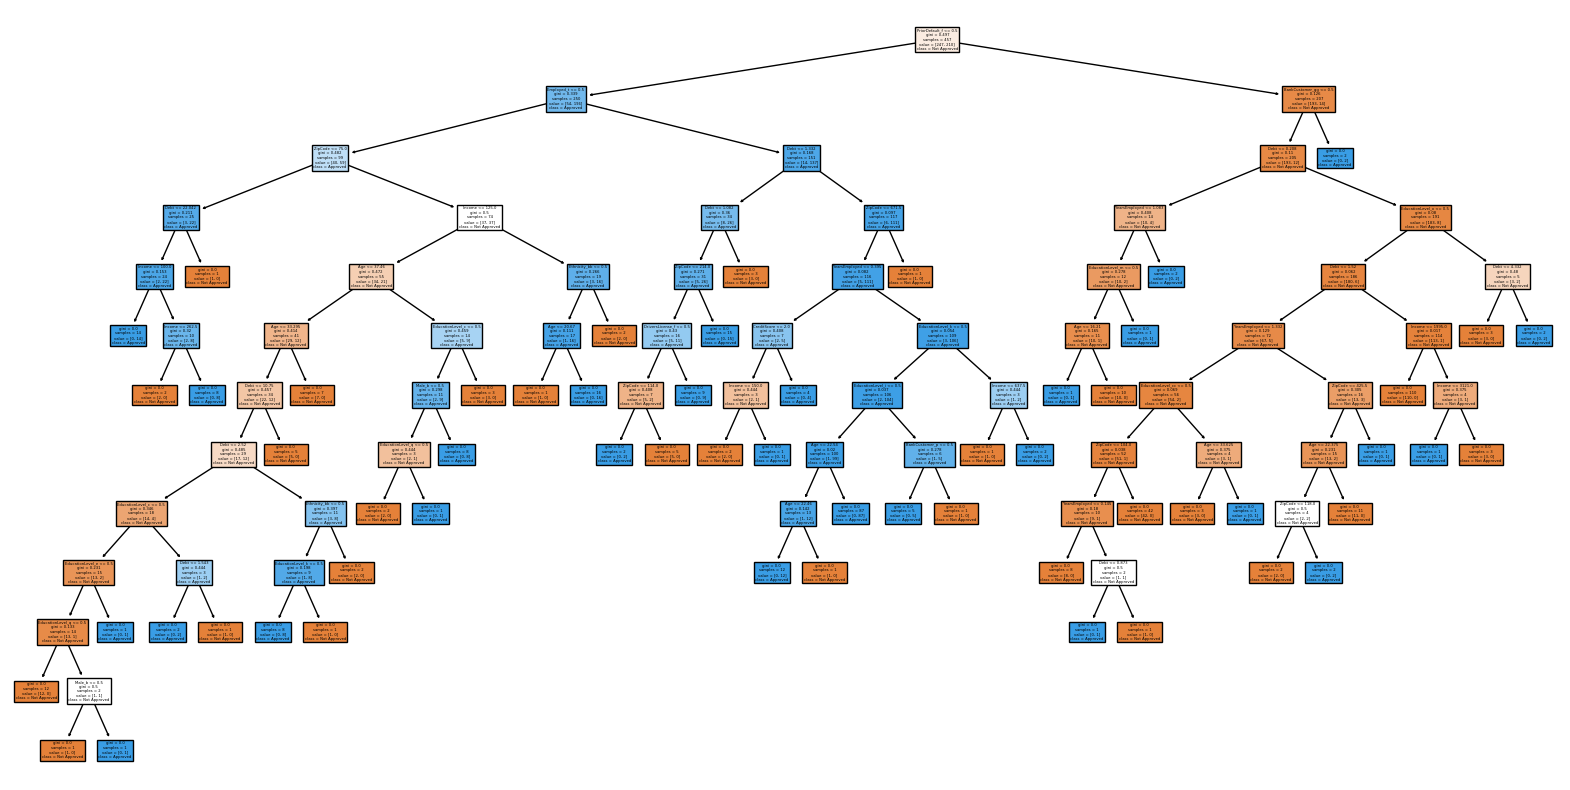

In [19]:
#Convert X.columns from Index to list
feature_names = X.columns.tolist()

# Visualize the decision tree
plt.figure(figsize=(20,10))
plot_tree(dtmodtrain, feature_names=feature_names, class_names=['Not Approved', 'Approved'], filled=True)
plt.show()


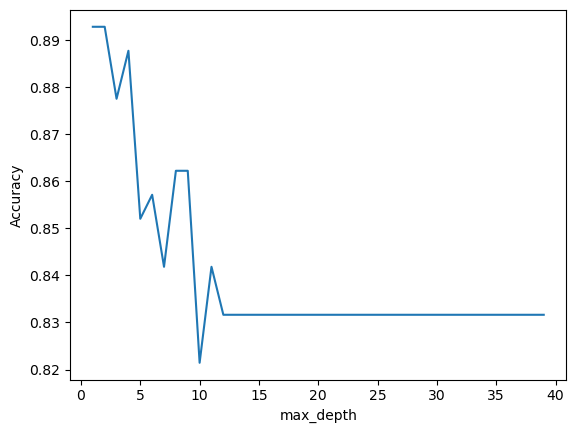

In [21]:
maxdepth = []
acc = []
for i in range(1, 40):
    dtmodtrain = tree.DecisionTreeClassifier(criterion='gini', max_depth=i, random_state=99)
    dtmodtrain.fit(X_train, Y_train)
    pred = dtmodtrain.predict(X_test)
    acc.append(accuracy_score(pred, Y_test))
    maxdepth.append(i)

data = pd.DataFrame({'acc': pd.Series(acc), 'maxdepth': pd.Series(maxdepth)})
plt.plot('maxdepth', 'acc', data=data)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.show()

### When we evaluated the decision tree model, we discovered a disparity between training and testing performance, which indicates overfitting. In particular, the model achieved a perfect training accuracy of 100%, whereas testing accuracy plateaued at around 83%. This indicates that, while the model perfectly fits the training data, it does not generalise effectively to new data. 

# Q6

In [20]:
dectree = tree.DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=99)
dectreemodel = dectree.fit(X_train, Y_train)
trainpredict = dectreemodel.predict(X_train)
acc = accuracy_score(trainpredict, Y_train)
print('Training Accuracy: ', acc * 100)

Training Accuracy:  89.93435448577681


### We observed a decrease in training accuracy. Now its almost 90% after applying pruning techniques to the decision tree by limiting its maximum depth to 4. This decrease in accuracy on training data indicates that the model's complexity was reduced, which is to be expected when pruning is used to prevent overfitting.

# Q7

   Num_Trees  Training_Accuracy  Testing_Accuracy  CV_Mean_Accuracy
5         52         100.000000         91.836735          0.853440
7         72         100.000000         91.836735          0.853440
8         82         100.000000         91.836735          0.857812
9         92         100.000000         91.836735          0.855638
10       102         100.000000         91.326531          0.857812
12       122         100.000000         91.326531          0.855638
18       182         100.000000         91.326531          0.853416
17       172         100.000000         91.326531          0.853416
16       162         100.000000         91.326531          0.851242
15       152         100.000000         91.326531          0.853416
14       142         100.000000         91.326531          0.857812
13       132         100.000000         91.326531          0.857812
19       192         100.000000         91.326531          0.853416
11       112         100.000000         91.32653

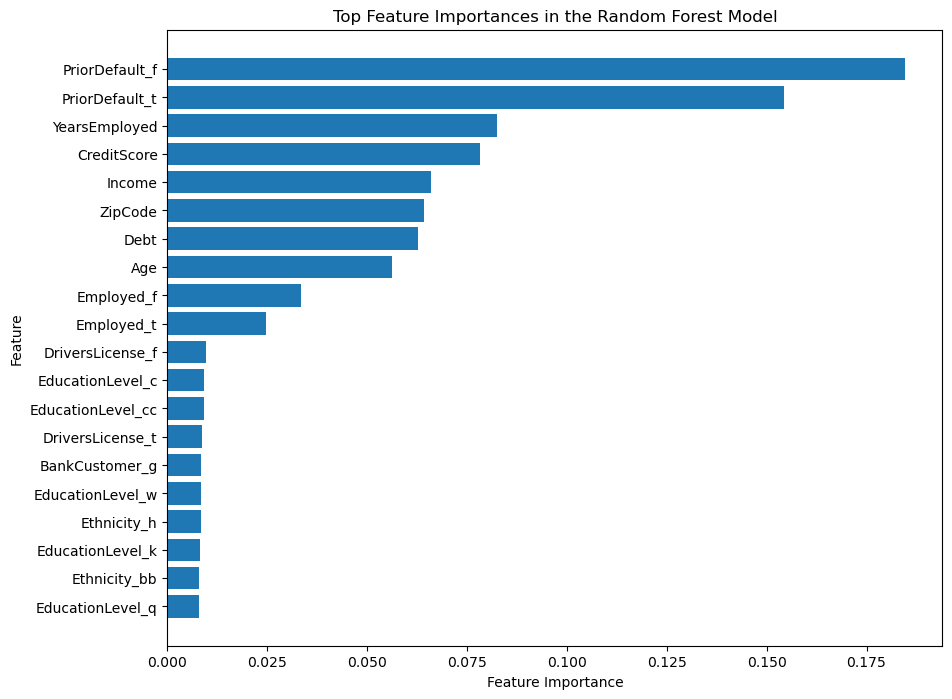

In [27]:
#Create a DataFrame to store accuracy results
results_df = pd.DataFrame(columns=['Num_Trees', 'Training_Accuracy', 'Testing_Accuracy', 'CV_Mean_Accuracy'])

num_of_trees_nodes = [i for i in range(2, 200, 10)]
best_testing_acc = 0
best_n_estimator = 0

for i in num_of_trees_nodes:
    forest = RandomForestClassifier(n_estimators=i, random_state=99)
    forest_model = forest.fit(X_train, Y_train)
    
    #Use cross-validation to get a better estimate of performance
    scores = cross_val_score(forest, X_train, Y_train, cv=5)
    
    train_predict = forest_model.predict(X_train)
    train_acc = accuracy_score(train_predict, Y_train) * 100
    test_predict = forest_model.predict(X_test)
    test_acc = accuracy_score(test_predict, Y_test) * 100
    
    #Create a temporary DataFrame with the new row of results
    temp_df = pd.DataFrame({'Num_Trees': [i], 'Training_Accuracy': [train_acc], 
                            'Testing_Accuracy': [test_acc], 'CV_Mean_Accuracy': [scores.mean()]})
    
    #Append the new row to the results DataFrame using concat
    results_df = pd.concat([results_df, temp_df], ignore_index=True)
    
    #Identify the model with the best testing accuracy
    if test_acc > best_testing_acc:
        best_testing_acc = test_acc
        best_n_estimator = i

#Print the DataFrame sorted by Testing_Accuracy
print(results_df.sort_values(by='Testing_Accuracy', ascending=False))

#Select the best model based on testing accuracy
best_forest = RandomForestClassifier(n_estimators=best_n_estimator, random_state=99)
best_forest_model = best_forest.fit(X_train, Y_train)

#Plot feature importances for the best model
sorted_idx = best_forest_model.feature_importances_.argsort()

#Decide how many top features to plot (for example, top 20)
top_n_features = 20

#Increase figure size for better readability
plt.figure(figsize=(10, 8))

#Plot feature importances for the best model
#Only take the top n features for a clearer plot
plt.barh(X_train.columns[sorted_idx][-top_n_features:], best_forest_model.feature_importances_[sorted_idx][-top_n_features:])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances in the Random Forest Model")
plt.show()

### It's obvious that as the number of trees in the Random Forest model grows, so do the training and testing accuracies, with the training accuracy reaching 100% fairly early on. This points to a possible overfitting scenario in which the model performs flawlessly on the training data. Because it is derived from multiple subsets of your data, the Cross-Validation (CV) Mean Accuracy provides a more generalised performance metric. This assists in determining how well the model would perform on untested data.


# Question 08

In [31]:
decisiontreescore = cross_val_score(dectreemodel, X, Y, cv=5)
print('Decision Tree Acuracy Score: ', decisiontreescore.mean())

randomforestscore = cross_val_score(best_forest_model, X, Y, cv=5)
print('Random Forest Accuracy Score: ', randomforestscore.mean())

Decision Tree Acuracy Score:  0.8207633587786258
Random Forest Accuracy Score:  0.8468467410452144


### We can deduce from this data that the RandomForest model has a 2.6 percentage point higher accuracy score. In terms of raw predictive power, this suggests that the RandomForest algorithm, which combines the predictions of several decision trees to produce a more accurate and robust model, outperforms the single Decision Tree model. Decision Tree model was prone to overfitting, requiring pruning to improve generalization. Decision Trees are more interpretable, but if the primary goal is predictive performance, Random Forests usually win. Consistency is not found in a single Decision Tree that can change significantly with small variations in the data.

# Reccomendation

# Q1

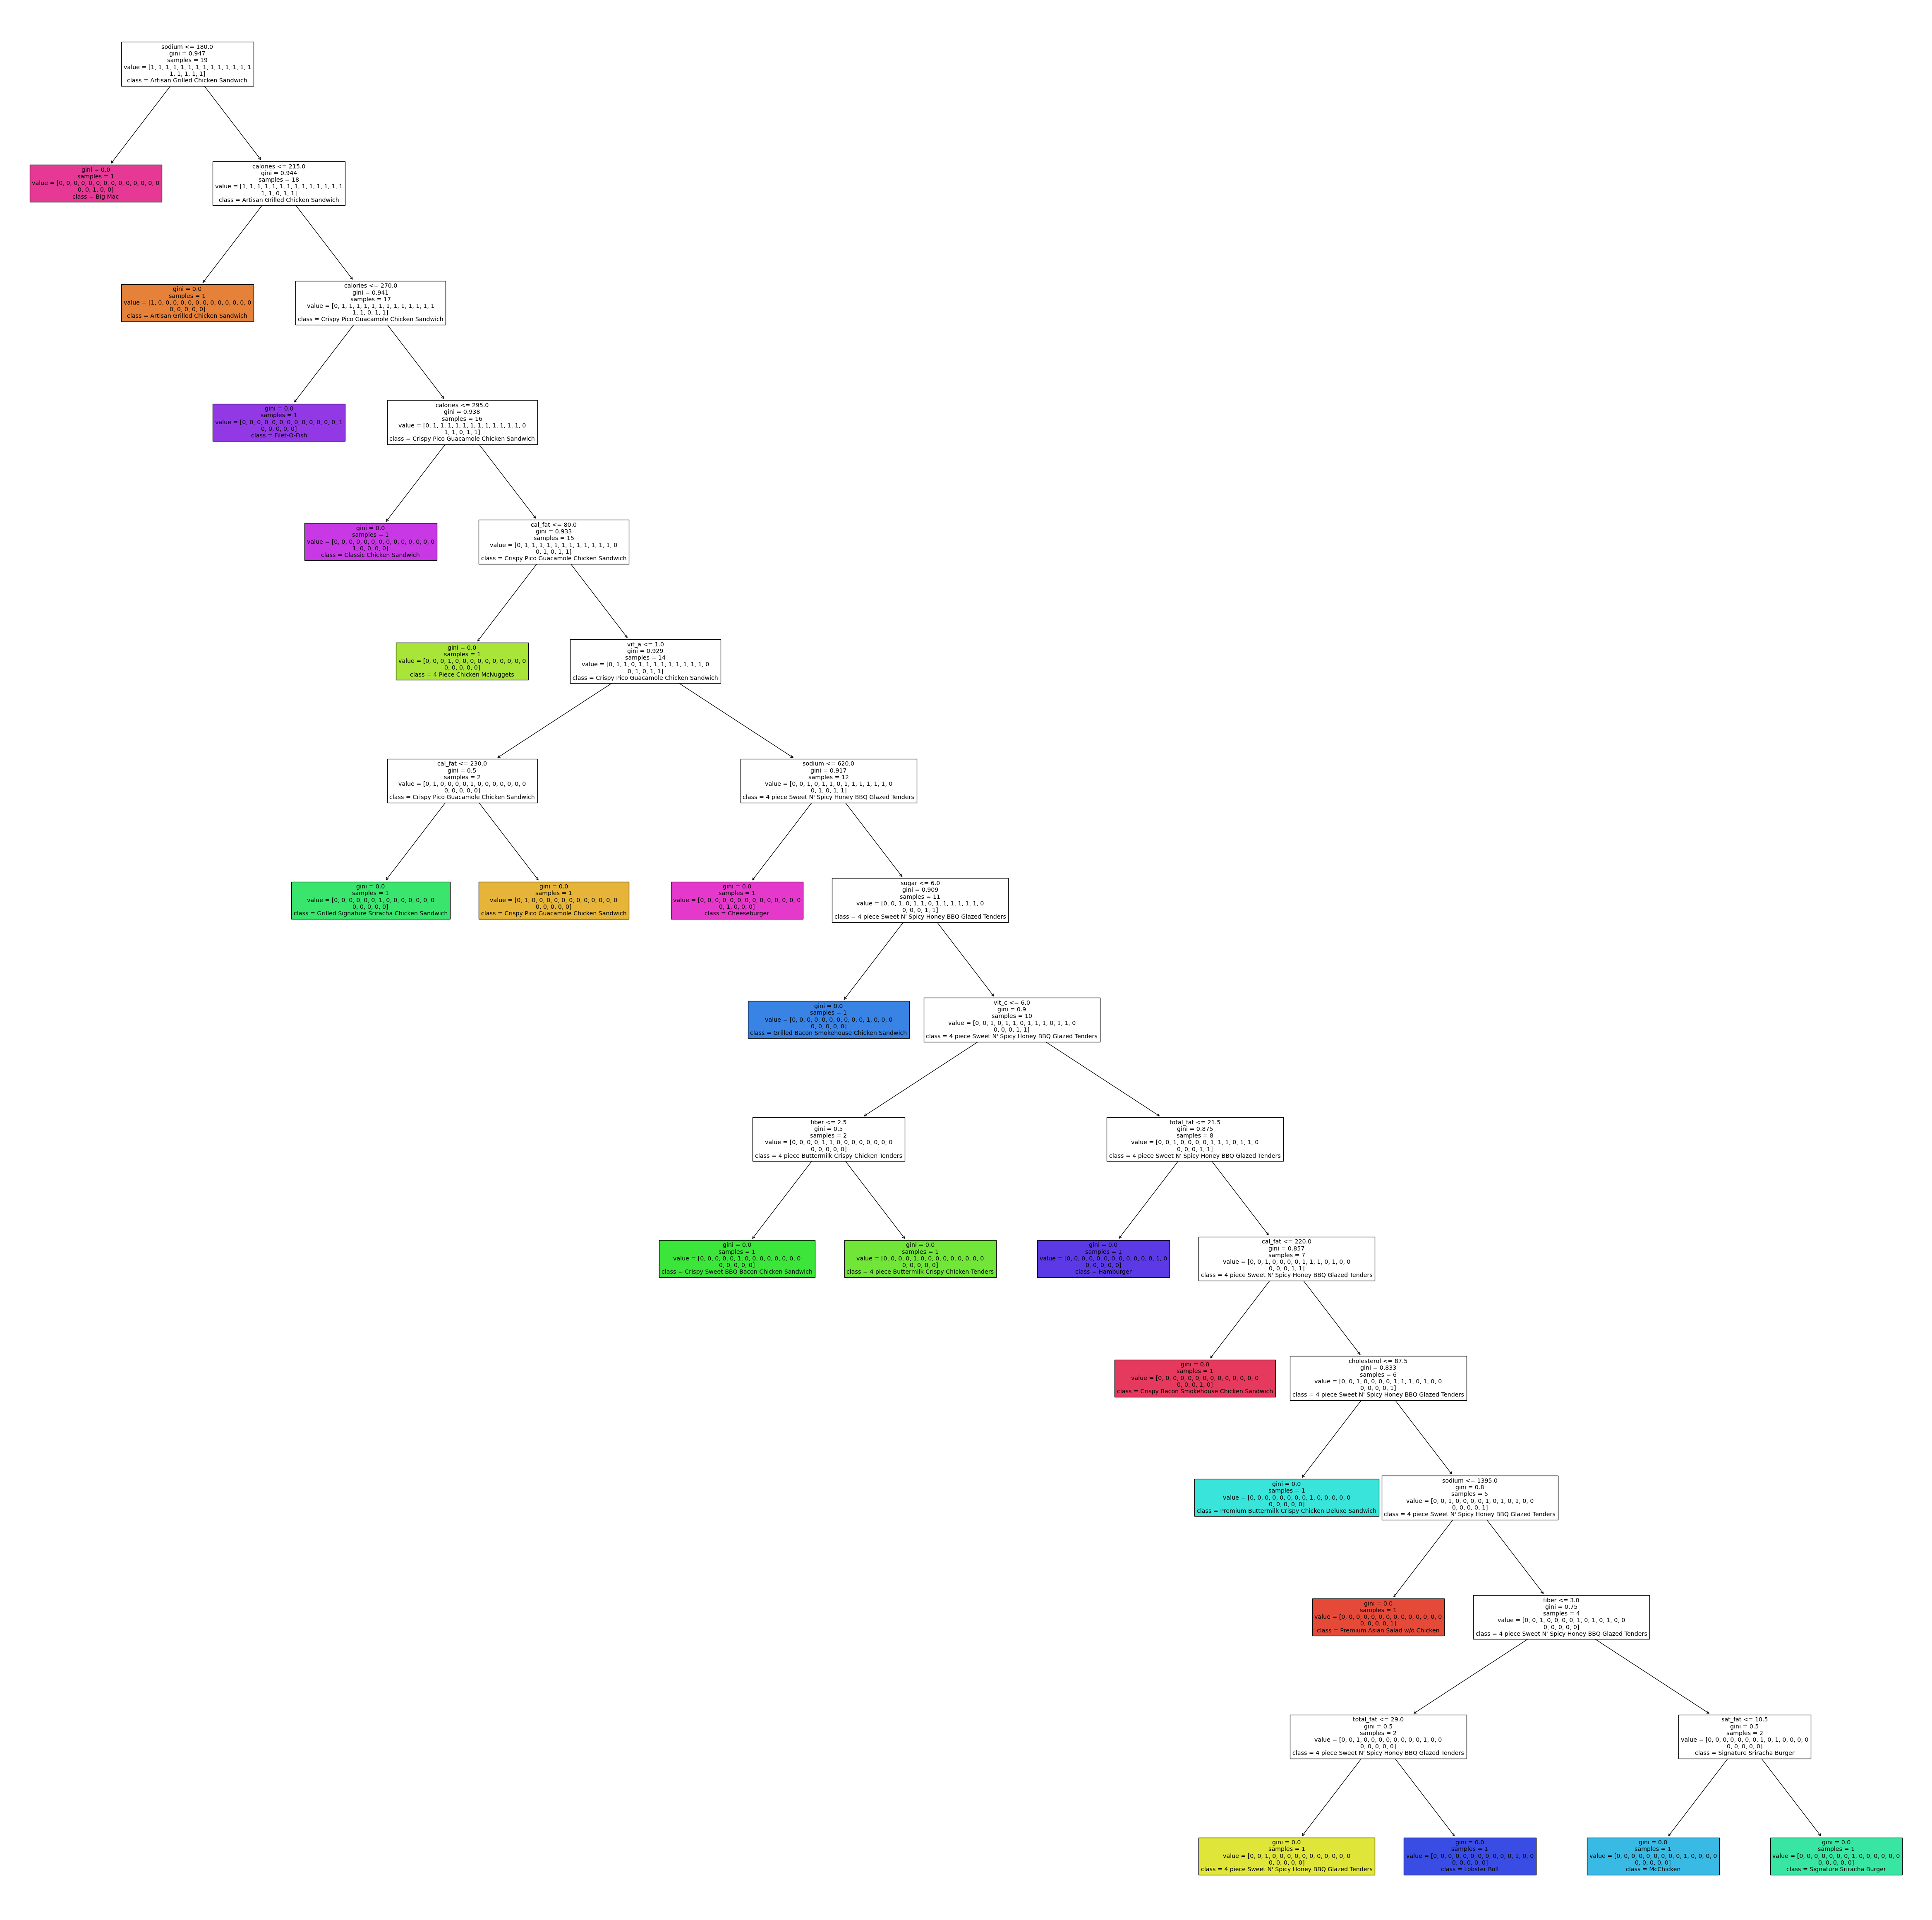

In [34]:
df2 = pd.read_csv('mcdonalds.csv')
df2 = df2.drop('restaurant', axis=1)
df2.head()
X = df2.drop('item', axis=1)
Y = df2['item']
dt = tree.DecisionTreeClassifier(criterion='gini', min_samples_split=2, min_samples_leaf=1, random_state=99)
dtmodel = dt.fit(X, Y)
dectreerepr = tree.export_text(dtmodel)
figure = plt.figure(figsize=(60, 60))
p = tree.plot_tree(dtmodel, feature_names=list(X.columns), class_names=Y.value_counts().index.tolist(), filled=True)

In [35]:
print(dectreerepr)

|--- feature_5 <= 180.00
|   |--- class: Premium Asian Salad w/o Chicken
|--- feature_5 >  180.00
|   |--- feature_0 <= 215.00
|   |   |--- class: 4 Piece Chicken McNuggets
|   |--- feature_0 >  215.00
|   |   |--- feature_0 <= 270.00
|   |   |   |--- class: Hamburger
|   |   |--- feature_0 >  270.00
|   |   |   |--- feature_0 <= 295.00
|   |   |   |   |--- class: Lobster Roll
|   |   |   |--- feature_0 >  295.00
|   |   |   |   |--- feature_1 <= 80.00
|   |   |   |   |   |--- class: Artisan Grilled Chicken Sandwich
|   |   |   |   |--- feature_1 >  80.00
|   |   |   |   |   |--- feature_10 <= 1.00
|   |   |   |   |   |   |--- feature_1 <= 230.00
|   |   |   |   |   |   |   |--- class: Classic Chicken Sandwich
|   |   |   |   |   |   |--- feature_1 >  230.00
|   |   |   |   |   |   |   |--- class: 4 piece Buttermilk Crispy Chicken Tenders
|   |   |   |   |   |--- feature_10 >  1.00
|   |   |   |   |   |   |--- feature_5 <= 620.00
|   |   |   |   |   |   |   |--- class: McChicken
|   | 

### We have to look at the leaf nodes of the decision tree. Food items that are located close to each other in the tree’s leaf nodes are potentially related, as they share similar attributes. The related food items can be identified by looking for the leaf nodes with a Gini index of 0. I will be choosing same children at the leaf and they will have the same parent. they differ by only one attribute based on the decision rule at that parent node.
## Similar Items:
### McChicken and Signature Siracha Burger
### Grilled Signature Siracha Chicken Sandwich and Crispy Pico Guacamole Chicken Sandwich
### 4 Peice honey bbq glazed tenders and Lobster Roll
